# 05 · Final Evaluation & Model Comparison

Loads best checkpoints for all models, runs test-set evaluation,
and generates all IEEE report figures.

**Checklist:**
- [ ] Notebooks 03 & 04 complete — checkpoints on Drive
- [ ] Runtime → **A100 GPU**

In [1]:
import os, sys, json, glob, torch

GITHUB_USER = 'musarashid49'
REPO_NAME   = 'Image-Classification-with-CNN'
REPO_DIR    = f'/content/{REPO_NAME}'

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Cloning into '/content/Image-Classification-with-CNN'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 64 (delta 22), reused 43 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 1.93 MiB | 11.75 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Mounted at /content/drive
Device: cuda


In [10]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────
LOCAL_DATA_DIR   = '/content/data'
DRIVE_SPLIT_PATH = '/content/drive/MyDrive/dataset_resplit'  # ← changed
DRIVE_RESULTS    = '/content/drive/MyDrive/pk_politicians_results'
# Restore checkpoints from Drive
import shutil
if os.path.isdir(DRIVE_RESULTS):
    for f in os.listdir(os.path.join(DRIVE_RESULTS, 'checkpoints')):
        src = os.path.join(DRIVE_RESULTS, 'checkpoints', f)
        dst = os.path.join('results', 'checkpoints', f)
        os.makedirs('results/checkpoints', exist_ok=True)
        shutil.copy2(src, dst)
    print('✓ Checkpoints restored from Drive')
else:
    print('⚠  No Drive results folder found — run Notebooks 03 & 04 first')

✓ Checkpoints restored from Drive


In [5]:
from src.utils import copy_dataset_from_drive, set_seed
from src.dataset import get_dataloaders

set_seed(42)
copy_dataset_from_drive(DRIVE_SPLIT_PATH, LOCAL_DATA_DIR)

loaders = get_dataloaders(
    os.path.join(LOCAL_DATA_DIR, 'train'),
    os.path.join(LOCAL_DATA_DIR, 'val'),
    os.path.join(LOCAL_DATA_DIR, 'test'),
)

  Global seed set to 42
  Copying dataset from Drive …
  Done in 426.3s  →  /content/data

── DataLoader Summary ──────────────────────────────────────
  train     1064 images  |    33 batches  |  classes: 16
  val        205 images  |     7 batches  |  classes: 16
  test       159 images  |     5 batches  |  classes: 16

  Class-to-index mapping:
    [ 0]  ahmed_sharif_chaudhry
    [ 1]  altaf_hussain
    [ 2]  asfandyar_wali
    [ 3]  asif_ali_zardari
    [ 4]  bilawal_bhutto
    [ 5]  chaudhry_nisar
    [ 6]  fazlur_rehman
    [ 7]  imran_khan
    [ 8]  maryam_nawaz
    [ 9]  nawaz_sharif
    [10]  pervez_khattak
    [11]  pervez_musharraf
    [12]  rana_sanaullah
    [13]  shah_mehmood_qureshi
    [14]  shehbaz_sharif
    [15]  sirajul_haq


In [11]:
# Check what's actually on Drive
import os

DRIVE_RESULTS = '/content/drive/MyDrive/pk_politicians_results'

print("Checking Drive for checkpoints...")
ckpt_dir = os.path.join(DRIVE_RESULTS, 'checkpoints')

if os.path.isdir(ckpt_dir):
    files = os.listdir(ckpt_dir)
    print(f"✓ Found {len(files)} checkpoint(s):")
    for f in files:
        size_mb = os.path.getsize(os.path.join(ckpt_dir, f)) / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")
else:
    print(f"✗ Checkpoint folder not found at {ckpt_dir}")

# Copy to local results folder
import shutil
os.makedirs('results/checkpoints', exist_ok=True)

if os.path.isdir(ckpt_dir):
    for f in os.listdir(ckpt_dir):
        if f.endswith('.pth'):
            src = os.path.join(ckpt_dir, f)
            dst = os.path.join('results/checkpoints', f)
            shutil.copy2(src, dst)
            print(f"✓ Copied {f} to local")
else:
    print("⚠ No checkpoints to copy")

Checking Drive for checkpoints...
✓ Found 3 checkpoint(s):
  .gitkeep  (0.0 MB)
  efficientnet_b0_best.pth  (16.4 MB)
  efficientnet_b2_best.pth  (31.4 MB)
✓ Copied efficientnet_b0_best.pth to local
✓ Copied efficientnet_b2_best.pth to local


⚠  Checkpoint not found: results/checkpoints/resnet50_best.pth  (skipping)

══ efficientnet_b0 ═══════════════════════════
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


  [efficientnet_b0]  trainable params: 4,028,044 / 4,028,044
  Checkpoint loaded: results/checkpoints/efficientnet_b0_best.pth
    epoch=23  val_acc=0.9220

── Classification Report [efficientnet_b0] ──────────────────
                       precision    recall  f1-score   support

ahmed_sharif_chaudhry       1.00      1.00      1.00         8
        altaf_hussain       1.00      1.00      1.00        11
       asfandyar_wali       1.00      1.00      1.00        11
     asif_ali_zardari       0.86      0.75      0.80         8
       bilawal_bhutto       1.00      0.88      0.93         8
       chaudhry_nisar       0.64      0.64      0.64        11
        fazlur_rehman       0.86      0.92      0.89        13
           imran_khan       0.77      1.00      0.87        10
         maryam_nawaz       0.81      0.93      0.87        14
         nawaz_sharif       1.00      1.00      1.00         8
       pervez_khattak       0.88      0.88      0.88         8
     pervez_musharraf   

100%|██████████| 35.2M/35.2M [00:00<00:00, 181MB/s]


  [efficientnet_b2]  trainable params: 7,723,538 / 7,723,538
  Checkpoint loaded: results/checkpoints/efficientnet_b2_best.pth
    epoch=15  val_acc=0.9317

── Classification Report [efficientnet_b2] ──────────────────
                       precision    recall  f1-score   support

ahmed_sharif_chaudhry       1.00      1.00      1.00         8
        altaf_hussain       0.92      1.00      0.96        11
       asfandyar_wali       0.92      1.00      0.96        11
     asif_ali_zardari       0.83      0.62      0.71         8
       bilawal_bhutto       1.00      0.75      0.86         8
       chaudhry_nisar       0.55      0.55      0.55        11
        fazlur_rehman       1.00      0.92      0.96        13
           imran_khan       0.77      1.00      0.87        10
         maryam_nawaz       0.68      0.93      0.79        14
         nawaz_sharif       0.80      1.00      0.89         8
       pervez_khattak       1.00      1.00      1.00         8
     pervez_musharraf   

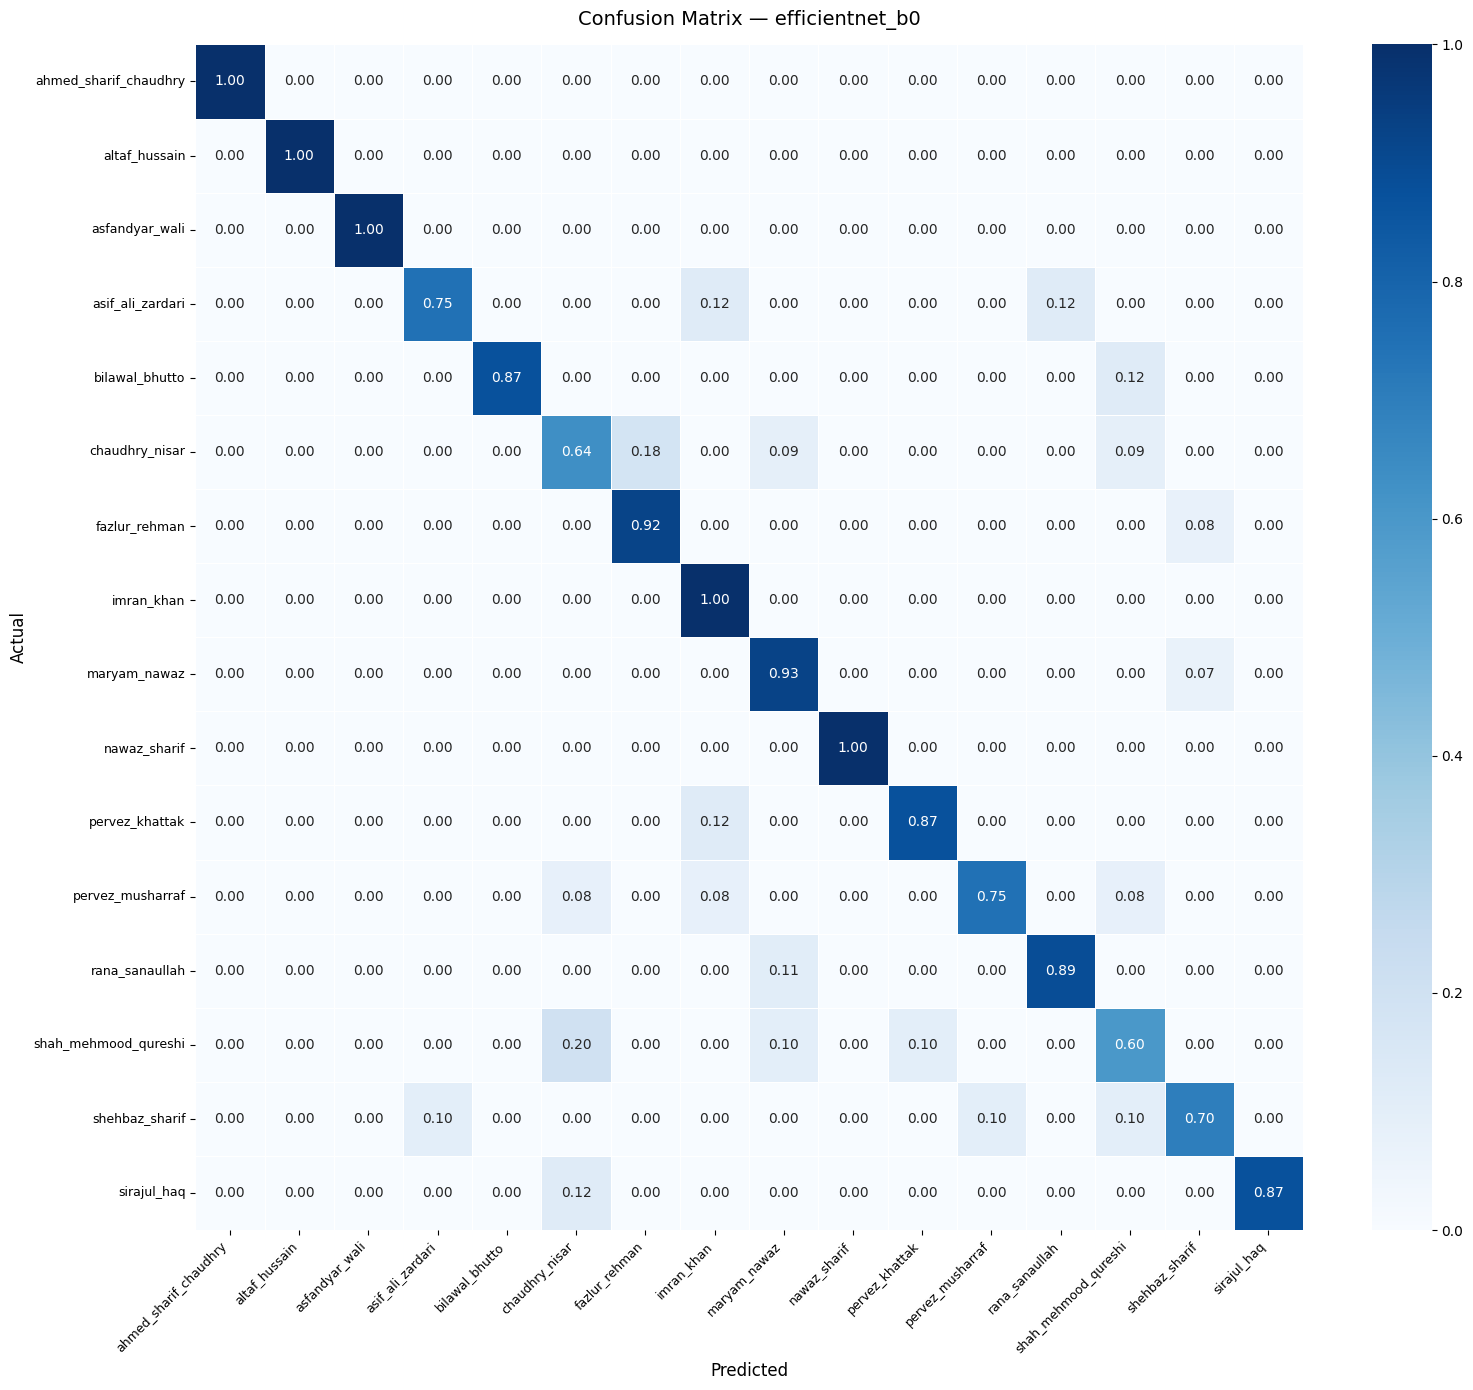

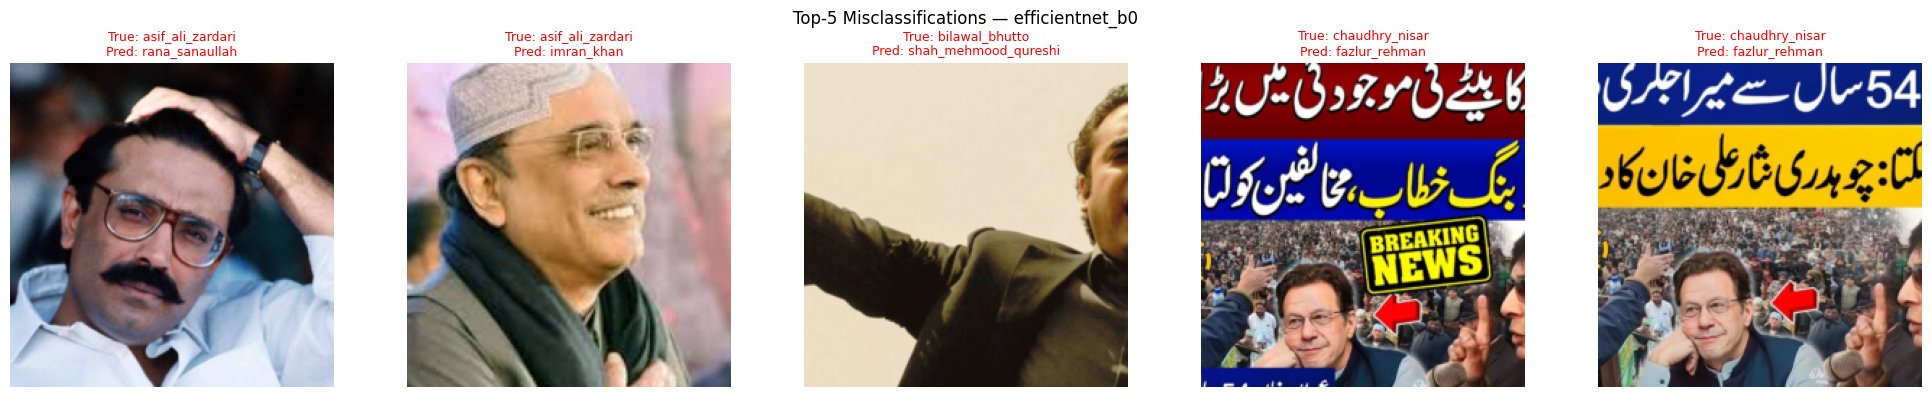

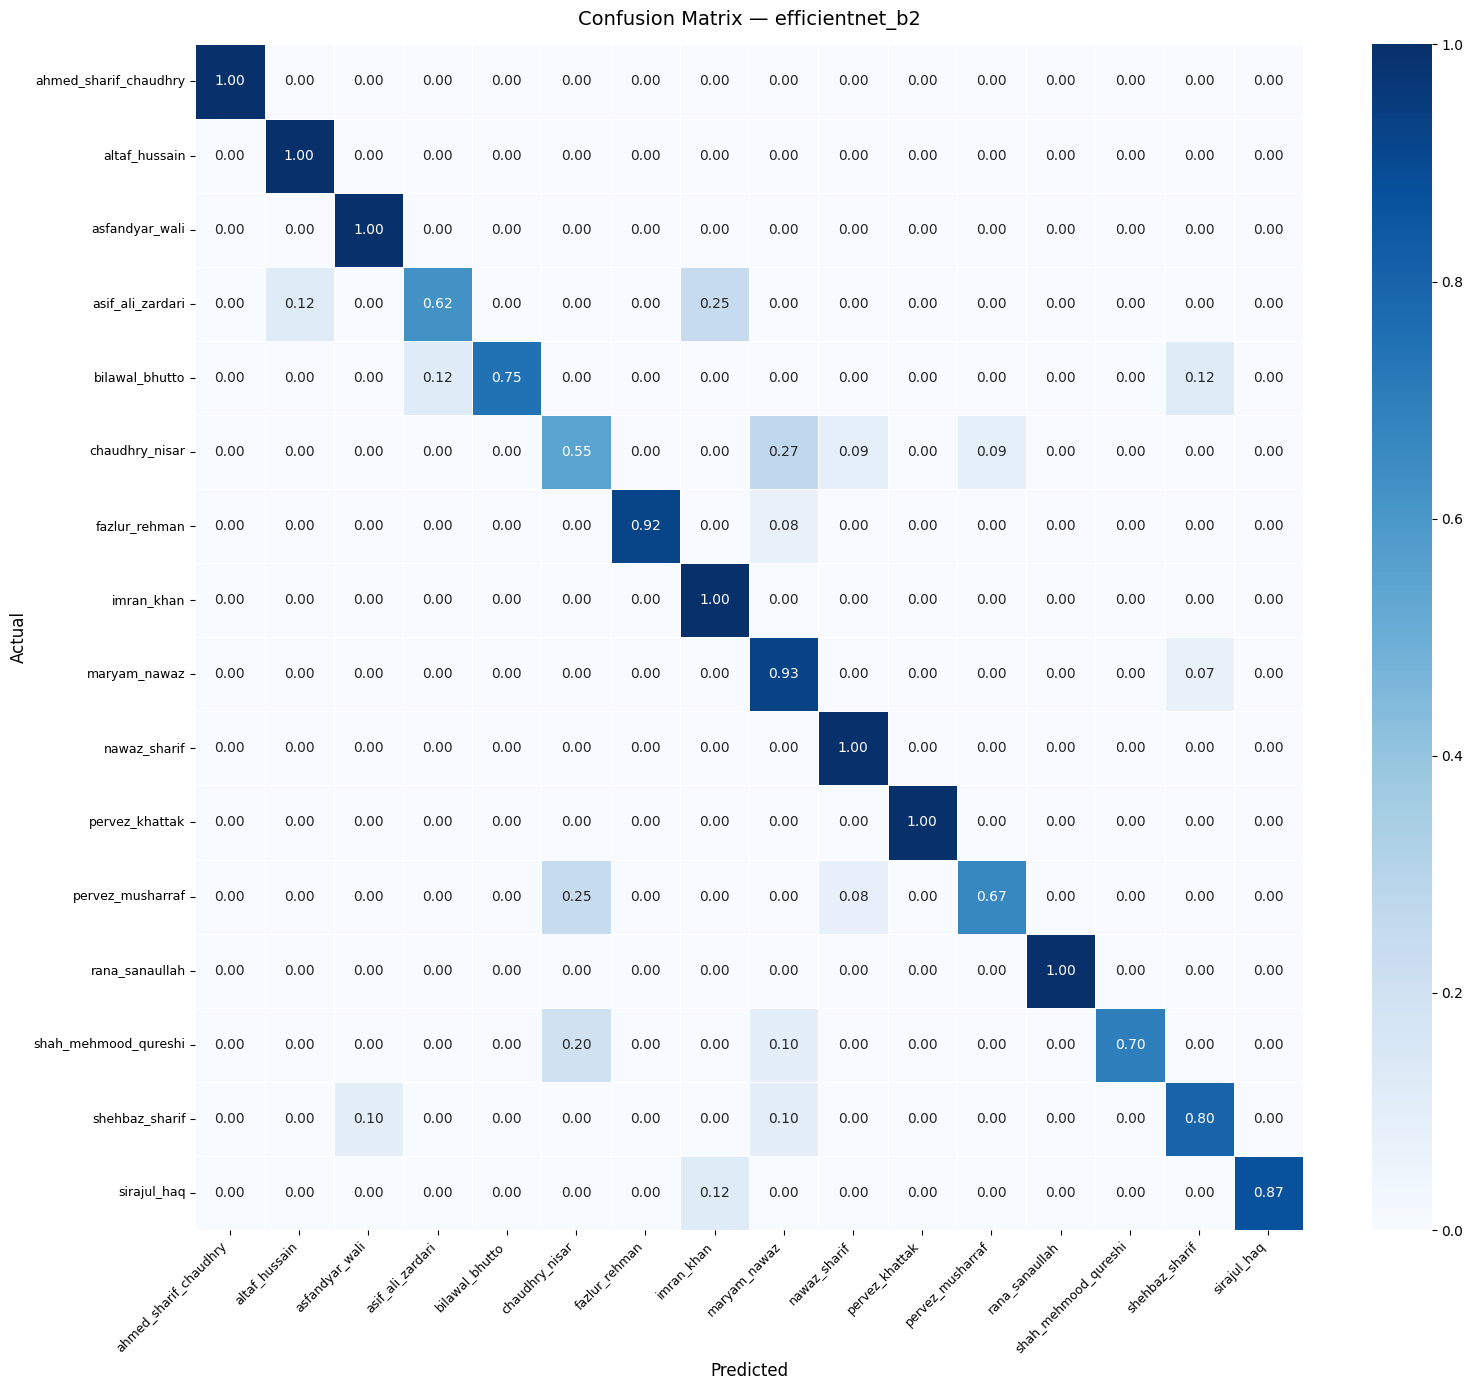

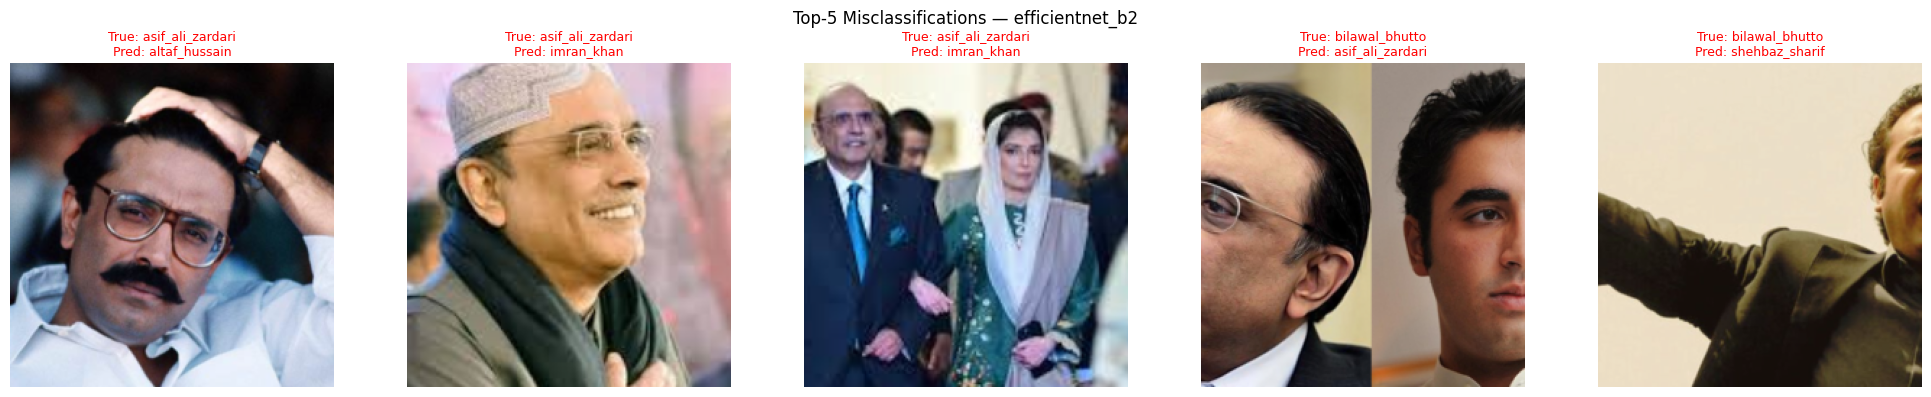

In [6]:
# Load checkpoints & evaluate all models
from src.models   import build_model
from src.utils    import load_checkpoint
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_misclassified

# Add/remove models from this dict as needed
CHECKPOINTS = {
    'resnet50':        'results/checkpoints/resnet50_best.pth',
    'efficientnet_b0': 'results/checkpoints/efficientnet_b0_best.pth',
    'efficientnet_b2': 'results/checkpoints/efficientnet_b2_best.pth',
}

all_results = {}
for model_name, ckpt_path in CHECKPOINTS.items():
    if not os.path.isfile(ckpt_path):
        print(f'⚠  Checkpoint not found: {ckpt_path}  (skipping)')
        continue
    print(f'\n══ {model_name} ═══════════════════════════')
    model = build_model(model_name, num_classes=16, dropout=0.4)
    load_checkpoint(model, ckpt_path, device)
    model.to(device)
    res = evaluate_model(model, loaders['test'], device, model_name=model_name)
    all_results[model_name] = res
    plot_confusion_matrix(res['y_true'], res['y_pred'], model_name=model_name).show()
    fig = plot_misclassified(res['images'], res['y_true'], res['y_pred'], model_name=model_name)
    if fig: fig.show()

In [9]:
# Training curves from saved JSON history files
from src.evaluate import plot_training_curves

for hist_file in sorted(glob.glob('results/metrics/*_history.json')):
    name = os.path.basename(hist_file).replace('_history.json', '')
    with open(hist_file) as f:
        history = json.load(f)
    plot_training_curves(history, model_name=name).show()

  Comparison chart saved → results/plots/model_comparison.png


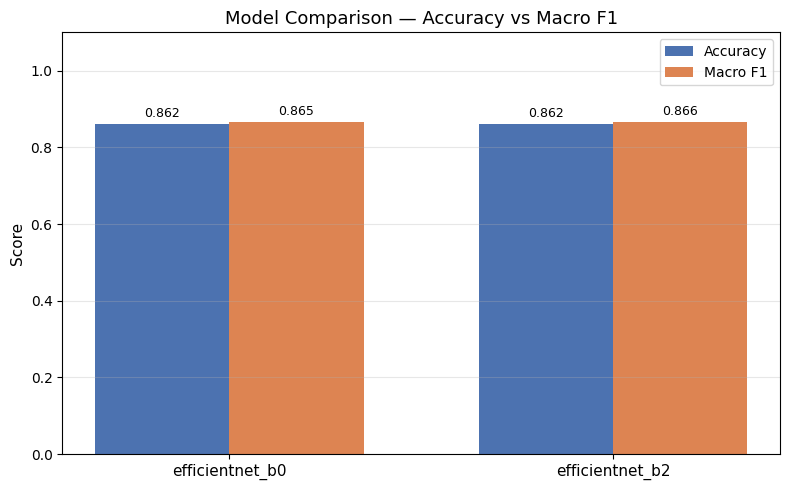

In [8]:
# Model comparison bar chart
from src.evaluate import plot_model_comparison

comparison_data = {
    name: {
        'accuracy': res['accuracy'],
        'macro_f1': res['report']['macro avg']['f1-score'],
    }
    for name, res in all_results.items()
}
plot_model_comparison(comparison_data).show()

In [12]:
# Summary table
from scripts.export_results import build_summary_table, build_per_class_table

print('\n── Summary ──────────────────────────────────────────────────')
df = build_summary_table()
print(df.to_string(index=False))

print('\n── Per-class F1 pivot ───────────────────────────────────────')
df_cls = build_per_class_table()
if not df_cls.empty:
    pivot = df_cls.pivot(index='class', columns='model', values='f1')
    print(pivot.to_string())


── Summary ──────────────────────────────────────────────────
          model  accuracy  precision  recall  f1_macro
efficientnet_b2    0.8616     0.8847  0.8634    0.8659
efficientnet_b0    0.8616     0.8734  0.8626    0.8654

── Per-class F1 pivot ───────────────────────────────────────
model                  efficientnet_b0  efficientnet_b2
class                                                  
ahmed_sharif_chaudhry           1.0000           1.0000
altaf_hussain                   1.0000           0.9565
asfandyar_wali                  1.0000           0.9565
asif_ali_zardari                0.8000           0.7143
bilawal_bhutto                  0.9333           0.8571
chaudhry_nisar                  0.6364           0.5455
fazlur_rehman                   0.8889           0.9600
imran_khan                      0.8696           0.8696
maryam_nawaz                    0.8667           0.7879
nawaz_sharif                    1.0000           0.8889
pervez_khattak                  0.875

In [13]:
# Push all final results to Drive
from src.utils import save_results_to_drive
save_results_to_drive('results', DRIVE_RESULTS)

# Also copy plots to report/figures/
import shutil
os.makedirs('report/figures', exist_ok=True)
for png in glob.glob('results/plots/*.png'):
    shutil.copy2(png, os.path.join('report/figures', os.path.basename(png)))

print('\n✓ All results saved.')
print('✓ Plots copied to report/figures/ — use for IEEE Overleaf report.')

  Saving results to Drive …
  Results saved → /content/drive/MyDrive/pk_politicians_results

✓ All results saved.
✓ Plots copied to report/figures/ — use for IEEE Overleaf report.
